# Finding Offsets Between TolTEC Observations

In [16]:
# load packages
%matplotlib inline
%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import cv2
from offset_functions import relative_pointing_offsets

In [17]:
# The reduction number you want to get observations from
redu_num = '63'
# The wavelength you want to align (choose between 1100, 1400, and 2000)
wav = '1100'
# The list of observations you want to align
obs_list = ['131947', '131949', '134710', '134712', '134714', '134859', '134861']
# The amount of pixels you want removed from the edges, set based on the reference image (a small crop value results in a messed up image)
crop = 150
# Optional parameters to include if the object of interest is not within the center of each image
x_push, y_push = 0, 0
# The maximum number of iterations undergone by relative_pointing_offsets
num_iter = 500
# The amount of cross-correlation change at which relative_pointing_offsets terminates
min_increment = 1e-10

In [18]:
center_list = [] # List of centerpixels for each observation
for obs in obs_list: # Loops over each observation
    # Opens the fits file header for the observation at the specified wavelength and at total intensity, assuming the below filepath
    header = fits.open('./redu' + redu_num + '/' + obs + '/raw/toltec_commissioning_a'
                       + wav + '_science_' + obs + '_citlali.fits')[1].header
    center = (int(header['CRPIX2']), int(header['CRPIX1'])) # Finds the centerpixel of the observation
    center_list.append(center)
    print(f'Observation {obs} Center (Pixels): {center}') # Printed in (y, x) format, which corresponds to (Dec, RA) in the WCS frame
    print()

Observation 131947 Center (Pixels): (253, 267)

Observation 131949 Center (Pixels): (272, 287)

Observation 134710 Center (Pixels): (265, 280)

Observation 134712 Center (Pixels): (277, 295)

Observation 134714 Center (Pixels): (289, 307)

Observation 134859 Center (Pixels): (276, 298)

Observation 134861 Center (Pixels): (284, 308)



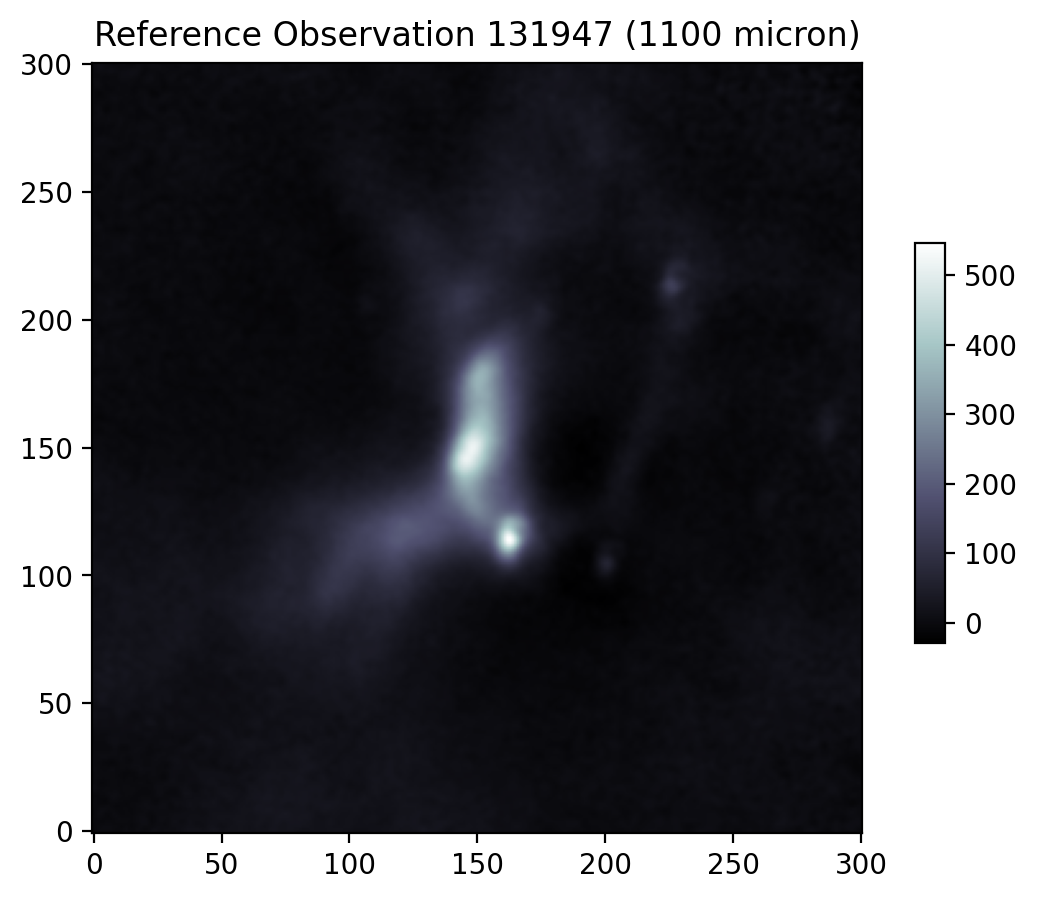

In [19]:
ref_obs = obs_list[0] # Chooses the first observation in obs_list as the reference observation
ref_center = center_list[0]

# The limits of the image are defined by a square of sidelength crop centered on the image's centerpixel and offset by x_push/y_push
ref_y_min, ref_y_max = ref_center[0]-crop-1+y_push, ref_center[0]+crop+y_push
ref_x_min, ref_x_max = ref_center[1]-crop-1+x_push, ref_center[1]+crop+x_push

# Obtains the reference observation image within the limits defined above at total intensity, assuming the below filepath
ref_img = fits.open('./redu' + redu_num + '/' + ref_obs + '/raw/toltec_commissioning_a' + wav + '_science_' 
                    + ref_obs + '_citlali.fits')[1].data[0][0][ref_y_min:ref_y_max, ref_x_min:ref_x_max]
fig, ax = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(5)
im = ax.imshow(ref_img, cmap='bone', origin='lower') # Plots image along with a colorbar corresponding to pixel flux value in mJy/beam
ax.set_title(f'Reference Observation {ref_obs} ({wav} micron)')
fig.colorbar(im, ax=ax, cax=fig.add_axes([0.95, 0.3, 0.03, 0.4]));

Reference Observation: 131947

Observation 131949
Maximized Enhanced Correlation Coefficient: 0.9929439695997999
X-shift (Arcseconds): -0.570862352848053
Y-shift (Arcseconds): 0.016001280397176743

Observation 134710
Maximized Enhanced Correlation Coefficient: 0.9790289438904021
X-shift (Arcseconds): -3.6520771980285645
Y-shift (Arcseconds): -3.9859209060668945

Observation 134712
Maximized Enhanced Correlation Coefficient: 0.978500331235308
X-shift (Arcseconds): -3.6823418140411377
Y-shift (Arcseconds): -1.684485673904419

Observation 134714
Maximized Enhanced Correlation Coefficient: 0.9756319370359964
X-shift (Arcseconds): 1.018517017364502
Y-shift (Arcseconds): 0.9781084060668945

Observation 134859
Maximized Enhanced Correlation Coefficient: 0.9736747424987692
X-shift (Arcseconds): 1.131037712097168
Y-shift (Arcseconds): -6.2622480392456055

Observation 134861
Maximized Enhanced Correlation Coefficient: 0.9728196222714253
X-shift (Arcseconds): 0.8280385732650757
Y-shift (Arcsecond

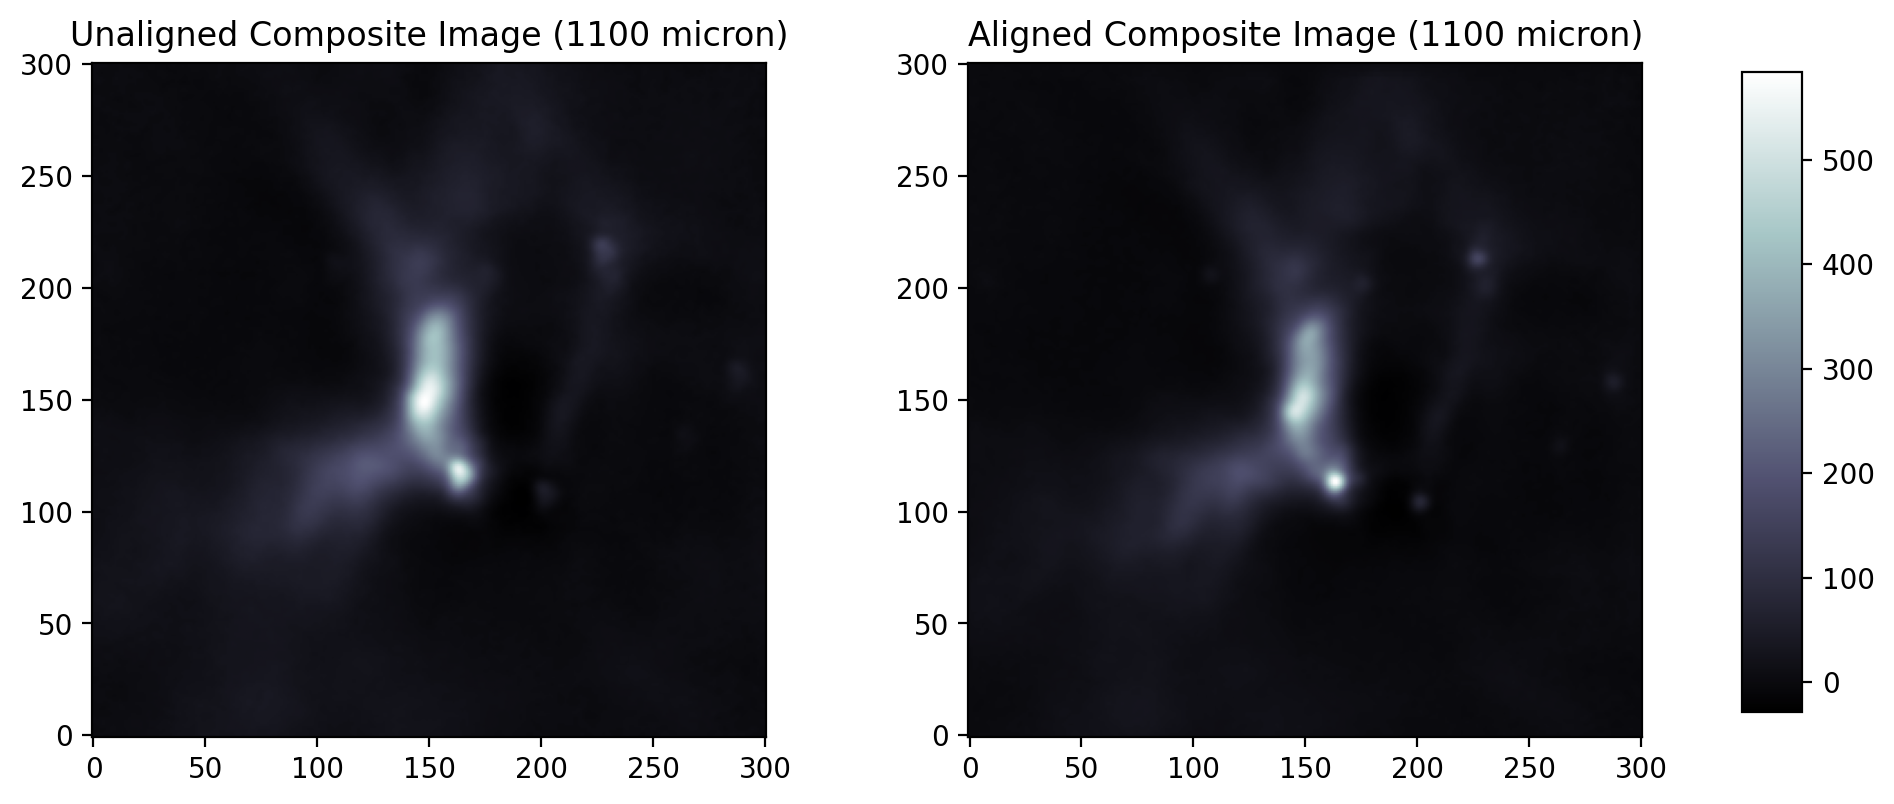

In [20]:
align_obsvs = obs_list[1:] # Chooses every other observation as observations to be aligned to the reference observation
align_centers = center_list[1:]

# Look at offset_functions.py for more info on relative_pointing_offsets
x_shifts, y_shifts, aligned_comp_img = relative_pointing_offsets(ref_obs, ref_center, align_obsvs, align_centers, wav, 
                                                                 redu_num, crop, num_iter, min_increment, x_push, y_push)

In [21]:
rel_offsets = [[0.0, 0.0]] # List of offsets from the reference observation for each observation
for (align_obs, x_shift, y_shift) in zip(align_obsvs, x_shifts, y_shifts): # Loops over each aligned observation and their offsets
    (align_dec_offset, align_ra_offset) = (float(y_shift), float(x_shift))
    rel_offsets.append([align_ra_offset, align_dec_offset]) # rel_offsets is in (RA, Dec) format
    print(f'Relative Offset of Observation {align_obs} (Dec, RA) (Arcseconds): {(align_dec_offset, align_ra_offset)}')
    print()

Relative Offset of Observation 131949 (Dec, RA) (Arcseconds): (0.016001280397176743, -0.570862352848053)

Relative Offset of Observation 134710 (Dec, RA) (Arcseconds): (-3.9859209060668945, -3.6520771980285645)

Relative Offset of Observation 134712 (Dec, RA) (Arcseconds): (-1.684485673904419, -3.6823418140411377)

Relative Offset of Observation 134714 (Dec, RA) (Arcseconds): (0.9781084060668945, 1.018517017364502)

Relative Offset of Observation 134859 (Dec, RA) (Arcseconds): (-6.2622480392456055, 1.131037712097168)

Relative Offset of Observation 134861 (Dec, RA) (Arcseconds): (-6.174765110015869, 0.8280385732650757)



In [22]:
mpa_list = [] # List of Mean Parallactic Angles for each observation
for obs in obs_list:
    header = fits.open('./redu' + redu_num + '/' + obs + '/raw/toltec_commissioning_a' + wav + '_science_' + obs + '_citlali.fits')[0].header
    mpa = header['MEAN_PA'] # The observation's Mean Parallactic Angle
    mpa_list.append(mpa*np.pi/180) # Transforms mpa into radians
    print(f'Mean Parallactic Angle of Observation {obs} (Degrees): {mpa}')
    print()

Mean Parallactic Angle of Observation 131947 (Degrees): 3.74800306262972

Mean Parallactic Angle of Observation 131949 (Degrees): 13.8351770922819

Mean Parallactic Angle of Observation 134710 (Degrees): 10.6909376601537

Mean Parallactic Angle of Observation 134712 (Degrees): 19.9333514014976

Mean Parallactic Angle of Observation 134714 (Degrees): 28.8281235412272

Mean Parallactic Angle of Observation 134859 (Degrees): 20.5809891421244

Mean Parallactic Angle of Observation 134861 (Degrees): 29.5863303228684



In [23]:
rel_offsets = np.array(rel_offsets)
mpa_list = np.array(mpa_list)
for (rel_offset, mpa, obs) in zip(rel_offsets, mpa_list, obs_list): # Loops over offsets, mpas, and observations
    cw_matrix = np.array([[np.cos(mpa), np.sin(mpa)], [-np.sin(mpa), np.cos(mpa)]]) # Clockwise rotation matrix about the mpa
    azalt_offset = (cw_matrix) @ (rel_offset) # Transforms offsets from the WCS frame into the local Az/Alt frame
    print(f'Relative Offsets to Input for Observation {obs} (Az, Alt) (Arcseconds): {(float(azalt_offset[0]), float(azalt_offset[1]))}')
    print()

# Input the below offsets into the pointing_offsets of each observation in your .yaml file

Relative Offsets to Input for Observation 131947 (Az, Alt) (Arcseconds): (0.0, 0.0)

Relative Offsets to Input for Observation 131949 (Az, Alt) (Arcseconds): (-0.5504739126985843, 0.15204715818414818)

Relative Offsets to Input for Observation 134710 (Az, Alt) (Arcseconds): (-4.328117944831835, -3.239232684665608)

Relative Offsets to Input for Observation 134712 (Az, Alt) (Arcseconds): (-4.036018465621016, -0.3281587515078367)

Relative Offsets to Input for Observation 134714 (Az, Alt) (Arcseconds): (1.3639202907688979, 0.36577918080269095)

Relative Offsets to Input for Observation 134859 (Az, Alt) (Arcseconds): (-1.142523965218712, -6.26016260173187)

Relative Offsets to Input for Observation 134861 (Az, Alt) (Arcseconds): (-2.3286210934152543, -5.778485601434488)

